<a href="https://colab.research.google.com/github/mun387344/netflix-data-analysis/blob/main/Netflix_Project_Muna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone Project
## Netflix Movies & TV Shows Analysis


### The five-step workflow
1. **Define** — one clear question
2. **Load & inspect** — read the file, look around
3. **Clean** — make the data analysis-ready
4. **Explore & visualize** — answer the question
5. **Insights** — say what it means


## Step 1 · Project Question

> **Headline question:** **Which years did Netflix add the most content, and what kind of content was added?**

### Objective

This project analyzes the Netflix catalogue dataset to identify the years when the most content was added and to compare the growth of Movies and TV Shows over time.

The analysis follows a complete data analysis workflow:
- Load and inspect the data
- Clean relevant columns
- Explore patterns using Pandas
- Visualize the findings
- Draw conclusions from the results


## Step 2 · Load & inspect




In [1]:
!pip install pandas


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('/netflix_titles.csv')
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
# Structure: types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [5]:
# Missing values per column
df.isna().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


**What we notice:**
- 8,807 rows, 12 columns.
- `date_added` is text (object) — we'll need to convert it.
- `duration` is text like "90 min" / "2 Seasons" — mixed formats.
- `director` (2,634), `cast` (825), and `country` (831) have lots of missing values.



## Step 3: Data Cleaning

For this project, only the columns needed to answer the research question are cleaned.

The `date_added` column is converted into a proper datetime format so that the year can be extracted. A new column called `year_added` is then created for analysis.

### 3.1 Parse `date_added` into a real date, pull out the year


In [6]:
# date_added looks like 'September 25, 2021' (with some stray spaces)
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), format='mixed', errors='coerce')
df['year_added'] = df['date_added'].dt.year

print("Missing date counts:", df['date_added'].isna().sum())
print("Year range:", df['year_added'].min(), "->", df['year_added'].max())

Missing date counts: 10
Year range: 2008.0 -> 2021.0


##3.2 Lets us verify that the extraction worked.

In [7]:
df[['date_added', 'year_added']].head()

,date_added,year_added
0,2021-09-25,2021.0
1,2021-09-24,2021.0
2,2021-09-24,2021.0
3,2021-09-24,2021.0
4,2021-09-24,2021.0


##3.3 Now let's check whether any dates could not be converted.

In [8]:
df['year_added'].isna().sum()

np.int64(10)

### Cleaning Summary

The following cleaning steps were performed:

- Converted the `date_added` column from text to datetime format.
- Created a new column called `year_added`.
- Verified that the conversion was successful.
- Checked for any missing values after conversion.

These cleaned columns will be used for the analysis and visualizations.

## Step 4: Data Exploration and Visualization

After cleaning the data, the next step is to explore patterns in the Netflix catalogue.

This analysis focuses on:
- The number of titles added each year.
- The distribution between Movies and TV Shows.
- How the mix of content has changed over time.

##4.1 Chart 1: Titles Added Each Year

In [9]:
titles_per_year = (
    df.dropna(subset=['year_added'])
      .groupby('year_added')
      .size()
)

titles_per_year.index = titles_per_year.index.astype(int)

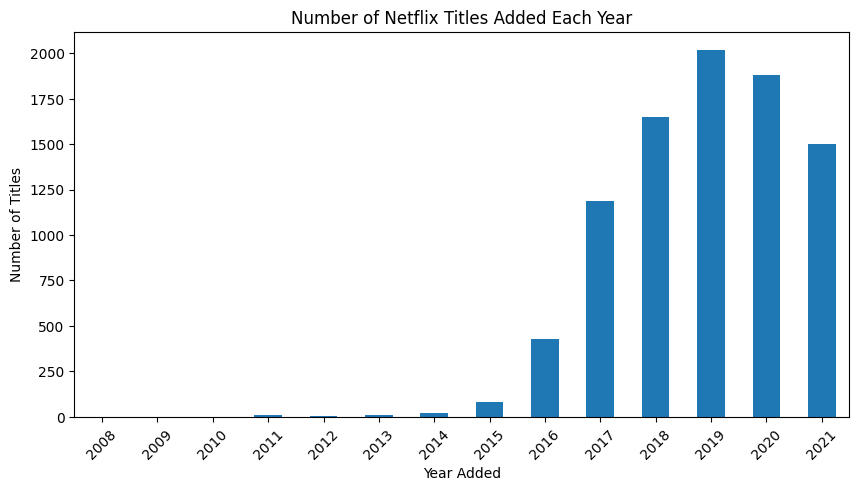

In [10]:
plt.figure(figsize=(10,5))

titles_per_year.plot(kind='bar')

plt.title('Number of Netflix Titles Added Each Year')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')

plt.xticks(rotation=45)

plt.show()

##Which year has the tallest bar?

2019

### Observation
The number of titles added to Netflix increased gradually before 2015 and then grew rapidly between 2016 and 2019. The highest number of additions occurred in 2019, with approximately 2,000 titles added to the catalogue. After 2019, the number of additions decreased slightly in 2020 and 2021.

##4.2 Movies vs TV Shows

In [11]:
content_type = df['type'].value_counts()
content_type

,count
type,
Movie,6131
TV Show,2676


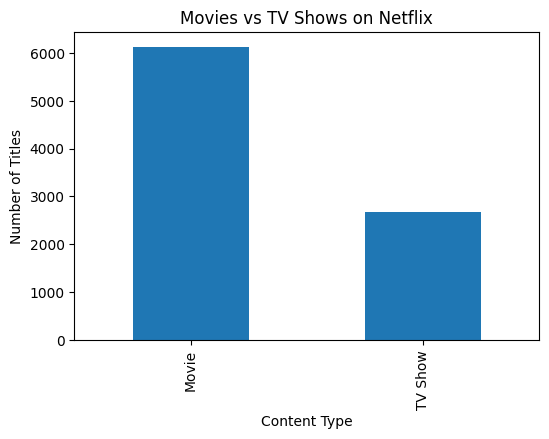

In [12]:
plt.figure(figsize=(6,4))

content_type.plot(kind='bar')

plt.title('Movies vs TV Shows on Netflix')
plt.xlabel('Content Type')
plt.ylabel('Number of Titles')

plt.show()

### Observation

The Netflix catalogue contains considerably more Movies than TV Shows. The dataset includes approximately 6,100 Movies and 2,700 TV Shows, indicating that Movies have historically been the dominant type of content on the platform.

##4.3 Movies and TV Shows Added by Year
This chart directly answers our project question.

In [13]:
year_type = df.groupby(['year_added', 'type']).size().unstack()

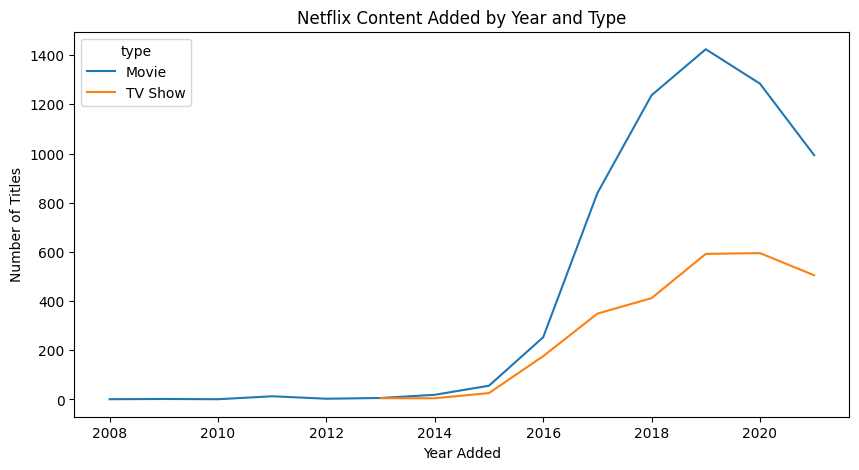

In [14]:
year_type.plot(figsize=(10,5))

plt.title('Netflix Content Added by Year and Type')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')

plt.show()

### Observation

Both Movies and TV Shows increased significantly after 2015. Movie additions reached their highest level in 2019, while TV Show additions also grew steadily during the same period. Although Movies remained more common throughout the dataset, the number of TV Shows expanded considerably over time.

In [15]:
print("Titles added each year:")
print(titles_per_year)

print("\n")

print("Content type counts:")
print(content_type)

Titles added each year:
year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     429
2017    1188
2018    1649
2019    2016
2020    1879
2021    1498
dtype: int64


Content type counts:
type
Movie      6131
TV Show    2676
Name: count, dtype: int64


#Step 5: Insights and Conclusion

This analysis investigated the question:

**"Which years did Netflix add the most content, and what kind of content was added?"**

The analysis produced three main findings:

1. Netflix expanded its catalogue rapidly after 2015, with content additions increasing sharply over the following years.

2. The largest number of titles was added in **2019**, making it the peak year for Netflix catalogue growth.

3. Movies make up the majority of the Netflix catalogue, with approximately **6,100 Movies** compared to about **2,700 TV Shows**. However, the number of TV Shows has increased steadily over time.

Overall, the results suggest that Netflix experienced its fastest period of growth between 2016 and 2019 while continuing to expand both its Movie and TV Show offerings. Although Movies remain the dominant content type, TV Shows have become an increasingly important part of the platform's catalogue.

### My Details

**Name: Muna Mohammed Husen**

**Email: munamk.freelancer@gmail.com**

**Country: Ethiopia**